In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
server = "DESKTOP-BKQN2OV\\SQLEXPRESS"
database = "olist_ecommerce"

conn_str = (
    "mssql+pyodbc://@"
    + server
    + "/"
    + database
    + "?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)

engine = create_engine(conn_str)

# Data loading
Caricamento dei dataset puliti da SQL Server e validazione dei tipi di dato in Pandas

In [3]:
clean_orders = pd.read_sql(
   "select * from clean_orders",
    engine
)

clean_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
 8   order_purchase_year            99441 non-null  int64         
 9   order_purchase_month           99441 non-null  int64         
 10  order_purchase_day             99441 non-null  int64         
 11  order_purchase_weekday    

In [4]:
clean_orders = clean_orders.astype({
    "order_approval_duration_hours": "Int64",
    "order_shipping_time_days": "Int64",
    "order_transit_time_days": "Int64",
    "order_delivery_time_days": "Int64",
    "order_delivery_delay_days": "Int64",
    "order_delivery_on_time_flag": "boolean",
    "order_seller_count": "Int64",
    "order_item_count": "Int64"
})

clean_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
 8   order_purchase_year            99441 non-null  int64         
 9   order_purchase_month           99441 non-null  int64         
 10  order_purchase_day             99441 non-null  int64         
 11  order_purchase_weekday    

In [5]:
clean_customers = pd.read_sql(
    "select * from clean_customers",
    engine
)

clean_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  str  
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: str(5)
memory usage: 3.8 MB


In [6]:
clean_geolocation = pd.read_sql(
    "select * from clean_geolocation",
    engine
)

clean_geolocation.info()

<class 'pandas.DataFrame'>
RangeIndex: 738332 entries, 0 to 738331
Data columns (total 5 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   geolocation_zip_code_prefix  738332 non-null  str    
 1   geolocation_lat              738332 non-null  float64
 2   geolocation_lng              738332 non-null  float64
 3   geolocation_city             738332 non-null  str    
 4   geolocation_state            738332 non-null  str    
dtypes: float64(2), str(3)
memory usage: 28.2 MB


In [7]:
clean_sellers = pd.read_sql(
    "select * from clean_sellers",
    engine
)

clean_sellers.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   str  
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: str(4)
memory usage: 96.8 KB


In [8]:
clean_products = pd.read_sql(
    "select * from clean_products",
    engine
)

clean_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_length         32341 non-null  float64
 3   product_description_length  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [9]:
clean_products = clean_products.astype({
    "product_name_length": "Int64",
    "product_description_length": "Int64",
    "product_photos_qty": "Int64"
})

clean_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_length         32341 non-null  Int64  
 3   product_description_length  32341 non-null  Int64  
 4   product_photos_qty          32341 non-null  Int64  
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: Int64(3), float64(4), str(2)
memory usage: 2.4 MB


In [10]:
clean_category_name_translation = pd.read_sql(
    "select * from clean_category_name_translation",
    engine
)

clean_category_name_translation.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


In [11]:
clean_order_items = pd.read_sql(
    "select * from clean_order_items",
    engine
)

clean_order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
 7   freight_ratio        112650 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(3)
memory usage: 6.9 MB


In [12]:
clean_order_payments = pd.read_sql(
    "select * from clean_order_payments",
    engine
)

clean_order_payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [13]:
clean_order_reviews = pd.read_sql(
    "select * from clean_order_reviews",
    engine
)

clean_order_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  str           
 1   order_id                 99224 non-null  str           
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  str           
 4   review_comment_message   40977 non-null  str           
 5   review_creation_date     99224 non-null  datetime64[us]
 6   review_answer_timestamp  99224 non-null  datetime64[us]
 7   review_answer_days       99224 non-null  int64         
dtypes: datetime64[us](2), int64(2), str(4)
memory usage: 6.1 MB


# Dataset Overview

## Orders
Il dataset *clean_orders* è composto da:
* 99441 righe
* 27 colonne
* nessuna riga duplicata

Le seguenti colonne presentano valori mancanti:
* *order_approved_at*
* *order_delivered_carrier_date*
* *order_delivered_customer_date*
* *order_approval_duration_hours*
* *order_shipping_time_days*
* *order_transit_time_days*
* *order_delivery_time_days*
* *order_delivery_delay_days*
* *order_delivery_on_time_flag*
* *order_delivery_status*
* *order_total_value*
* *order_total_freight_value*
* *order_total_freight_ratio*
* *order_total_amount*
* *order_payment_gap*
* *order_item_count*
* *order_seller_count*

Considerando *order_purchase_timestamp* come riferimento temporale, il dataset copre il periodo compreso tra il 2016-09-04 e il 2018-10-17.

In [14]:
clean_orders.shape

(99441, 27)

In [15]:
clean_orders.duplicated().sum()

np.int64(0)

In [16]:
clean_orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
order_purchase_year                 0
order_purchase_month                0
order_purchase_day                  0
order_purchase_weekday              0
order_purchase_quarter              0
order_approval_duration_hours     160
order_shipping_time_days         1783
order_transit_time_days          2966
order_delivery_time_days         2965
order_delivery_delay_days        2965
order_delivery_on_time_flag      2965
order_delivery_status            2965
order_total_value                 775
order_total_freight_value         775
order_total_freight_ratio         775
order_total_amount                775
order_payment_gap                 776
order_item_count                  775
order_seller

In [17]:
(
    clean_orders["order_purchase_timestamp"].min(),
    clean_orders["order_purchase_timestamp"].max()
)

(Timestamp('2016-09-04 21:15:19'), Timestamp('2018-10-17 17:30:18'))

## Customers

Il dataset *clean_customers* è composta da:

* 99441 righe
* 5 colonne
* nessuna riga duplicata
* nessun valore mancante

In [18]:
clean_customers.shape

(99441, 5)

In [19]:
clean_customers.duplicated().sum()

np.int64(0)

In [20]:
clean_customers.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

## Geolocation

Il dataset *clean_geolocation* è composto da:

* 738332 righe
* 5 colonne
* 179 righe duplicate
* nessun valore mancante

In [21]:
clean_geolocation.shape

(738332, 5)

In [22]:
clean_geolocation.duplicated().sum()

np.int64(179)

In [23]:
clean_geolocation.isna().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

## Sellers
Il dataset *clean_sellers* è composto da:
* 3095 righe
* 4 colonne
* nessuna riga duplicata
* nessun valore mancante

In [24]:
clean_sellers.shape

(3095, 4)

In [25]:
clean_sellers.duplicated().sum()

np.int64(0)

In [26]:
clean_sellers.isna().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

## Products
Il dataset *clean_products* è composto da:

* 32951 righe
* 9 colonne
* nessuna riga duplicata

Le seguenti colonne presentano valori mancanti:

* *product_category_name*
* *product_name_length*
* *product_description_length*
* *product_photos_qty*
* *product_weight_g*
* *product_length_cm*
* *product_height_cm*
* *product_width_cm*

In [27]:
clean_products.shape

(32951, 9)

In [28]:
clean_products.duplicated().sum()

np.int64(0)

In [29]:
clean_products.isna().sum()

product_id                      0
product_category_name         610
product_name_length           610
product_description_length    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

## Category Name Translation

Il dataset è composto da:

* 71 righe
* 2 colonne
* nessuna riga duplicata
* nessun valore mancante

In [30]:
clean_category_name_translation.shape

(71, 2)

In [31]:
clean_category_name_translation.duplicated().sum()

np.int64(0)

In [32]:
clean_category_name_translation.isna().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

## Order Items
Il dataset è composto da:
* 112650 righe
* 8 colonne
* nessuna riga duplicata
* nessun valore mancante

In [33]:
clean_order_items.shape

(112650, 8)

In [34]:
clean_order_items.duplicated().sum()

np.int64(0)

In [35]:
clean_order_items.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
freight_ratio          0
dtype: int64

## Order Payments
Il dataset è composto da:
* 103886 righe
* 5 colonne
* nessuna riga duplicata
* nessun valore mancante

In [36]:
clean_order_payments.shape

(103886, 5)

In [37]:
clean_order_payments.duplicated().sum()

np.int64(0)

In [38]:
clean_order_payments.isna().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

## Order Reviews
Il dataset è composto da:
* 99224 righe
* 8 colonne
* nessuna riga duplicata

Le seguenti colonne presentano valori mancanti:
* *review_comment_title*
* *review_comment_message*

Considerando *review_creation_date* come riferimento temporale, il dataset copre il periodo che va dal 2016-10-02 al 2018-08-31.

In [39]:
clean_order_reviews.shape

(99224, 8)

In [40]:
clean_order_reviews.duplicated().sum()

np.int64(0)

In [41]:
clean_order_reviews.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
review_answer_days             0
dtype: int64

In [42]:
(
    clean_order_reviews["review_creation_date"].min(),
    clean_order_reviews["review_creation_date"].max()
)

(Timestamp('2016-10-02 00:00:00'), Timestamp('2018-08-31 00:00:00'))

# Data Quality Check

## Orders

I valori mancanti in *order_approved_at* riguardano ordini con *order_status* compresi tra **created**, **canceled** e **delivered**. Se per i primi due l'assenza della data di approvazione risulta coerente con il dataset, per gli ordini **delivered** si tratta probabilmente di an'anomalia di sistema.

Inoltre, i valori mancanti in *order_item_count* riguardano ordini con il seguente *order_status*:

* 603 ordini **unavailable**
* 164 ordini **canceled**
* 5 ordini **created**
* 2 ordini **invoiced**
* 1 ordine **shipped**

Gli ordini **unavailable**, **canceled** e **created** possono essere coerenti con un *order_item_count* mancante. Mentre è meno probabile che un ordine **invoiced** o **shipped** non contenga almeno un articolo: non avrebbe senso fatturare o spedire un ordine vuoto. Per questo motivo, si segnalano questi tre ordini con *order_item_count* mancante come anomalie nel dataset.

Le restanti colonne non presentano anomalie strutturali. In particolare, tutte le colonne, ad eccezione di *order_delivered_carrier_date* e *order_delivered_customer_date*, presentano valori mancanti in quanto feature derivate da colonne con valori mancanti (di questo dataset o di *clean_order_items*).

In [43]:
clean_orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
order_purchase_year                 0
order_purchase_month                0
order_purchase_day                  0
order_purchase_weekday              0
order_purchase_quarter              0
order_approval_duration_hours     160
order_shipping_time_days         1783
order_transit_time_days          2966
order_delivery_time_days         2965
order_delivery_delay_days        2965
order_delivery_on_time_flag      2965
order_delivery_status            2965
order_total_value                 775
order_total_freight_value         775
order_total_freight_ratio         775
order_total_amount                775
order_payment_gap                 776
order_item_count                  775
order_seller

In [44]:
clean_orders.loc[
    clean_orders["order_approved_at"].isna(),
    "order_status"
].value_counts()

order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64

In [45]:
clean_orders.loc[
    clean_orders["order_seller_count"].isna(),
    "order_status"
].value_counts()

order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

## Customers
Il data quality check non evidenzia anomalie strutturali nei dati.

## Geolocation

Le righe duplicate non presentano un problema, in quanto il dataset ha funzione di LUT geografico e non verrà utilizzato per estrarre KPI.

## Sellers
Il data quality check non evidenzia anomalie strutturali nei dati.

## Products

I valori mancanti non presentano un problema, in quanto il dataset ha funzione di dimension table e gli attributi mancanti forniscono maggiori informazioni che non verranno utilizzati per estrarre direttamente KPI.

## Category Name Translation
Il data quality check non evidenzia anomalie strutturali nei dati.

## Order Items
Il data quality check non evidenzia anomalie strutturali nei dati.

## Order Payments
Il data quality check non evidenzia anomalie strutturali nei dati.

## Order Reviews
I valori mancanti fanno riferimento a campi testuali opzionali. La loro assenza è coerente con la natura del dato e non rappresenta un'anomalia strutturale.

# Univariate Analysis

## Orders

### Categorical
Dall'analisi di *order_status* e *order_delivery_status* viene fuori che circa il 97% degli ordini è in stato **delivered**, la cui consegna è avvenuta per il:
* 74% in *super_early*
* 18% in *early*
* 7% in *delayed* o *severely_delayed*
* 1% in *on_time*

In sostanza, le consegne sono state piuttosto celeri, con solo il 7% di ritardi.

P.S. Si precisa che l'analisi inerente a *order_delivery_status* è stata condotta sull'intero dataset, senza escludere gli 8 ordini **delivered** che non hanno un *order_delivery_status* o i 6 ordini *canceled* che, al contrario, hanno un *order_delivery_status*.

#### Order Status

In [46]:
clean_orders["order_status"].value_counts(normalize=True)

order_status
delivered      0.970203
shipped        0.011132
canceled       0.006285
unavailable    0.006124
invoiced       0.003158
processing     0.003027
created        0.000050
approved       0.000020
Name: proportion, dtype: float64

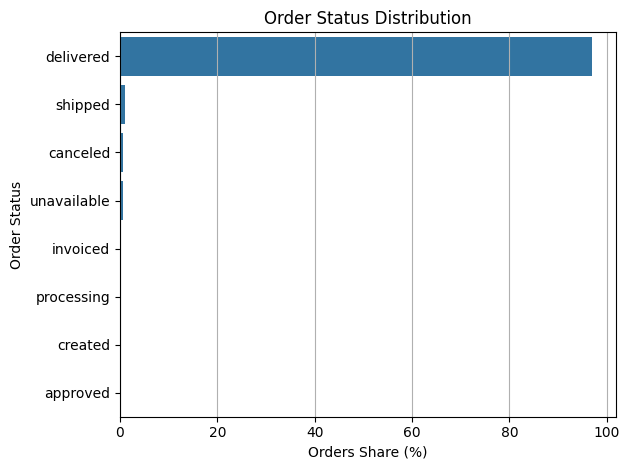

In [47]:
sns.countplot(
    data=clean_orders,
    y="order_status",
    order=clean_orders["order_status"].value_counts().index,
    stat="percent"
)
plt.title("Order Status Distribution")
plt.xlabel("Orders Share (%)")
plt.ylabel("Order Status")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

#### Order Delivery Status

In [48]:
clean_orders["order_delivery_status"].value_counts(normalize=True)

order_delivery_status
super_early         0.739127
early               0.179744
delayed             0.038061
severely_delayed    0.029676
on_time             0.013392
Name: proportion, dtype: float64

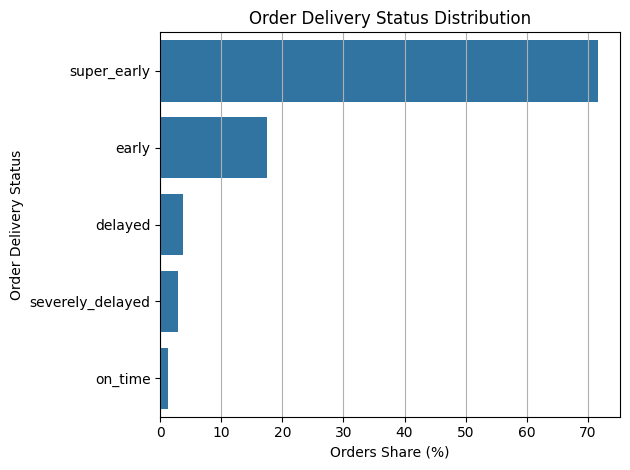

In [49]:
sns.countplot(
    data=clean_orders,
    y="order_delivery_status",
    order=clean_orders["order_delivery_status"].value_counts().index,
    stat="percent"
)
plt.title("Order Delivery Status Distribution")
plt.xlabel("Orders Share (%)")
plt.ylabel("Order Delivery Status")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

In [50]:
clean_orders.loc[
    clean_orders["order_status"] == 'delivered',
    "order_delivery_status"
].isna().sum()

np.int64(8)

In [51]:
clean_orders.query(
    "order_status != 'delivered' & order_delivery_status.notnull()"
)["order_status"].value_counts()

order_status
canceled    6
Name: count, dtype: int64

### Numerical
Dall'analisi di *order_total_value* e *order_total_amount* viene fuori che entrambe le distribuzioni sono fortemente right-skewed, con una concentrazione di valori nel range interquartile e una lunga coda a destra. Da entrambi i boxplot si osserva la presenza di outlier al di sopra del baffo superiore, indicando l'esistenza di ordini con un valore totale piuttosto elevato rispetto a quello medio.

Anche le distribuzioni di *order_total_freight_value* e *order_total_freight_ratio* sono fortemente asimmetriche, con una lunga coda verso destra e diversi outlier.

La distribuzione di *order_item_count* presenta una media di 1.14 e una deviazione standard pari a 0.54, mostrando che un ordine contiene raramente più di un articolo. Anche la distribuzione di *order_seller_count* è analoga, con in media di 1.01 venditori per ordine e una deviazione standard di 0.12: la quasi totalità degli ordini è evasa da un singolo venditore, con alcuni outlier che non superano i 5. Data l'altissima concentrazione di valori bassi, non è stato riportato il boxplot per queste due variabili in quanto non aggiunge informazioni.

Infine, la colonna *order_payment_gap* presenta una forte concentrazione di valori intorno allo zero e pochi valori estremi, sia positivi che negativi, per via di una differenza interquartile pari a 0 e una deviazione standard pari a 1.13. Ciò significa che per la maggior parte degli ordini non c'è differenza tra valore commerciale e importo effettivamente pagato dal cliente.

#### Order Total Value

In [52]:
clean_orders["order_total_value"].describe()

count    98666.000000
mean       137.754076
std        210.645145
min          0.850000
25%         45.900000
50%         86.900000
75%        149.900000
max      13440.000000
Name: order_total_value, dtype: float64

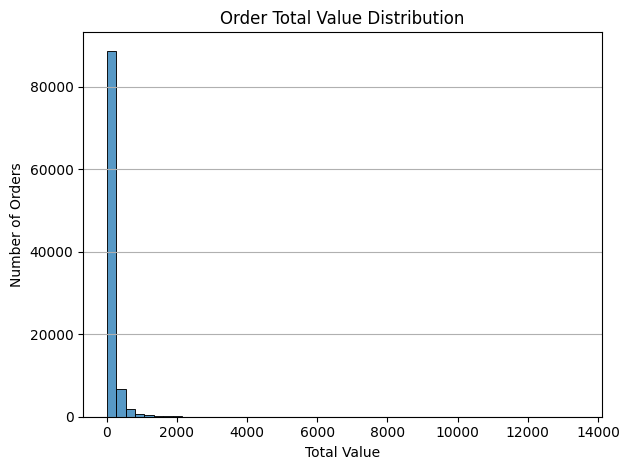

In [53]:
sns.histplot(
    data=clean_orders,
    x="order_total_value",
    bins=50
)
plt.title("Order Total Value Distribution")
plt.xlabel("Total Value")
plt.ylabel("Number of Orders")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

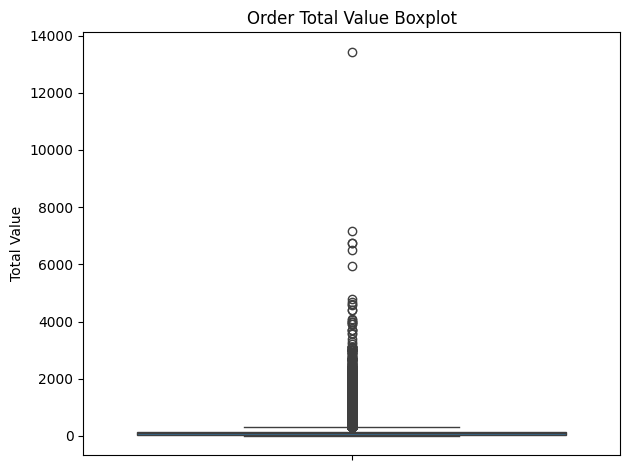

In [54]:
sns.boxplot(
    data=clean_orders,
    y="order_total_value"
)
plt.title("Order Total Value Boxplot")
plt.ylabel("Total Value")
plt.tight_layout()
plt.show()

#### Order Total Amount

In [55]:
clean_orders["order_total_amount"].describe()

count    98666.000000
mean       160.577638
std        220.466087
min          9.590000
25%         61.980000
50%        105.290000
75%        176.870000
max      13664.080000
Name: order_total_amount, dtype: float64

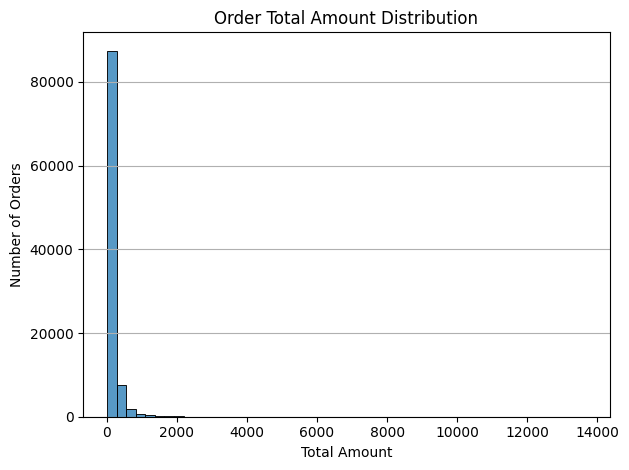

In [56]:
sns.histplot(
    data=clean_orders,
    x="order_total_amount",
    bins=50
)
plt.title("Order Total Amount Distribution")
plt.xlabel("Total Amount")
plt.ylabel("Number of Orders")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

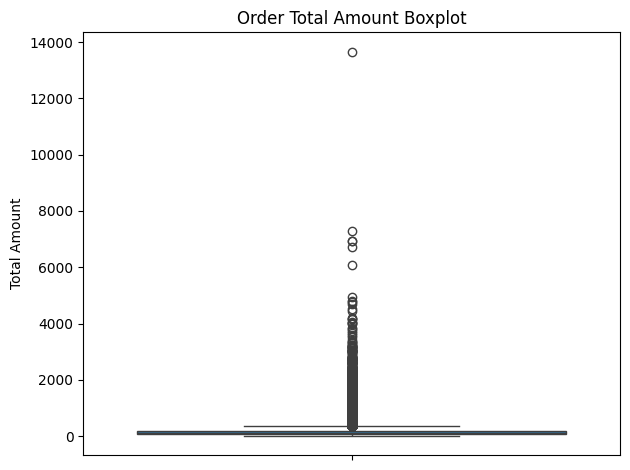

In [57]:
sns.boxplot(
    data=clean_orders,
    y="order_total_amount"
)
plt.title("Order Total Amount Boxplot")
plt.ylabel("Total Amount")
plt.tight_layout()
plt.show()

#### Order Total Freight Value

In [58]:
clean_orders["order_total_freight_value"].describe()

count    98666.000000
mean        22.823562
std         21.650909
min          0.000000
25%         13.850000
50%         17.170000
75%         24.040000
max       1794.960000
Name: order_total_freight_value, dtype: float64

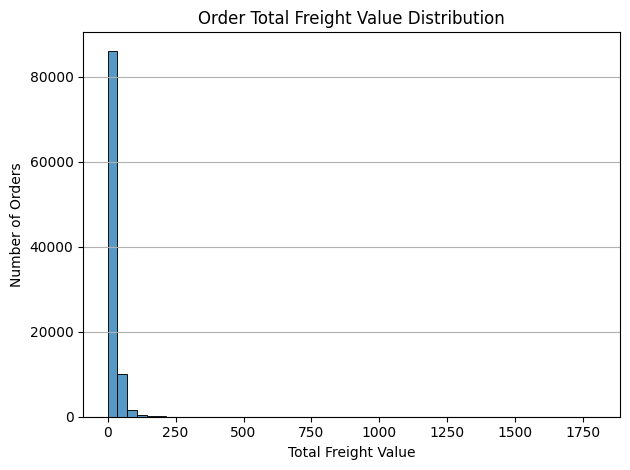

In [59]:
sns.histplot(
    data=clean_orders,
    x="order_total_freight_value",
    bins=50
)
plt.title("Order Total Freight Value Distribution")
plt.xlabel("Total Freight Value")
plt.ylabel("Number of Orders")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

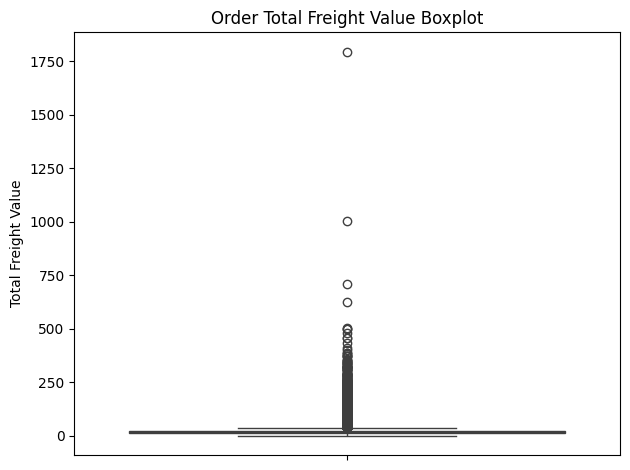

In [60]:
sns.boxplot(
    data=clean_orders,
    y="order_total_freight_value"
)
plt.title("Order Total Freight Value Boxplot")
plt.ylabel("Total Freight Value")
plt.tight_layout()
plt.show()

#### Order Total Freight Ratio

In [61]:
clean_orders["order_total_freight_ratio"].describe()

count    98666.000000
mean         0.308389
std          0.314762
min          0.000000
25%          0.131900
50%          0.224400
75%          0.380200
max         21.447100
Name: order_total_freight_ratio, dtype: float64

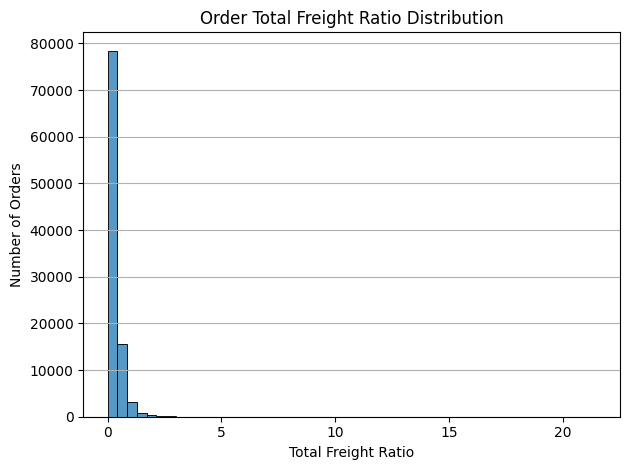

In [62]:
sns.histplot(
    data=clean_orders,
    x="order_total_freight_ratio",
    bins=50
)
plt.title("Order Total Freight Ratio Distribution")
plt.xlabel("Total Freight Ratio")
plt.ylabel("Number of Orders")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

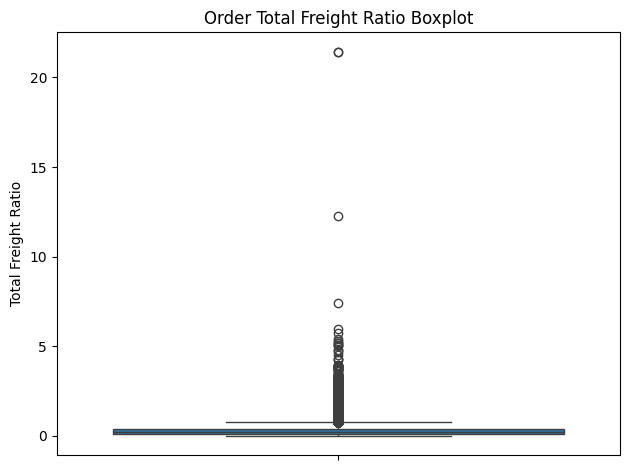

In [63]:
sns.boxplot(
    data=clean_orders,
    y="order_total_freight_ratio"
)
plt.title("Order Total Freight Ratio Boxplot")
plt.ylabel("Total Freight Ratio")
plt.tight_layout()
plt.show()

#### Order Item Count

In [64]:
clean_orders["order_item_count"].describe()

count     98666.0
mean     1.141731
std      0.538452
min           1.0
25%           1.0
50%           1.0
75%           1.0
max          21.0
Name: order_item_count, dtype: Float64

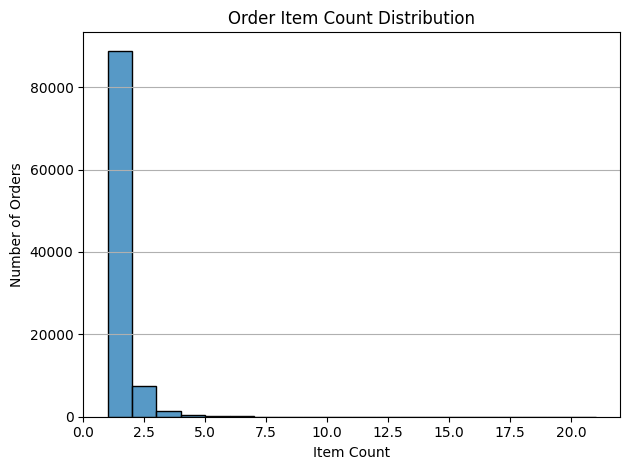

In [65]:
sns.histplot(
    data=clean_orders,
    x="order_item_count",
    bins=np.arange(1,clean_orders["order_item_count"].max()+1)
)
plt.title("Order Item Count Distribution")
plt.xlabel("Item Count")
plt.ylabel("Number of Orders")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

#### Order Seller Count

In [66]:
clean_orders["order_seller_count"].describe()

count     98666.0
mean     1.013622
std      0.122297
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           5.0
Name: order_seller_count, dtype: Float64

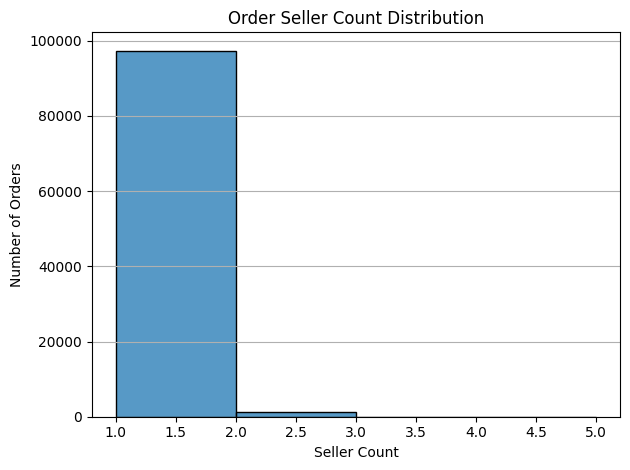

In [67]:
sns.histplot(
    data=clean_orders,
    x="order_seller_count",
    bins=np.arange(1, clean_orders["order_seller_count"].max()+1)
)
plt.title("Order Seller Count Distribution")
plt.xlabel("Seller Count")
plt.ylabel("Number of Orders")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

#### Order Payment Gap

In [68]:
clean_orders["order_payment_gap"].describe()

count    98665.000000
mean         0.029092
std          1.129221
min        -51.620000
25%          0.000000
50%          0.000000
75%          0.000000
max        182.810000
Name: order_payment_gap, dtype: float64

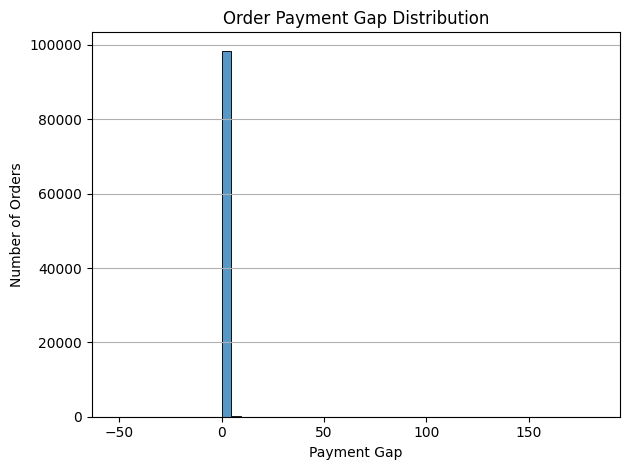

In [69]:
sns.histplot(
    data=clean_orders,
    x="order_payment_gap",
    bins=50
)
plt.title("Order Payment Gap Distribution")
plt.xlabel("Payment Gap")
plt.ylabel("Number of Orders")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

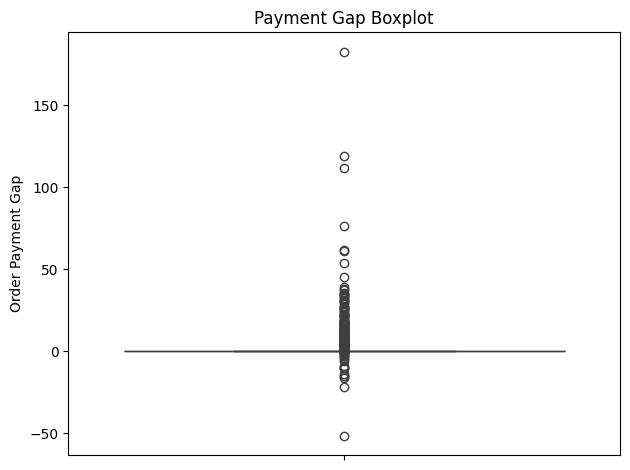

In [70]:
sns.boxplot(
    data=clean_orders,
    y="order_payment_gap"
)
plt.title("Payment Gap Boxplot")
plt.ylabel("Order Payment Gap")
plt.tight_layout()
plt.show()

### Temporal
La colonna *order_purchase_timestamp* comprende ordini d'acquisto che vanno dal 2016-09-04 al 2018-10-17, senza alcun valore mancante. Durante questo periodo, si nota un trend di crescita mensili degli ordini, con un valore medio superiore ai 6.000 ordini nel periodo compreso tra novembre 2017 e agosto 2018.
Si evidenzia che nel mese di novembre 2016 non ci sono ordini, così come a settembre e dicembre dello stesso anno e a settembre e ottobre 2018 la mole di ordini è prossima allo zero: è presumibile che il dataset sia incompleto.
Se consideriamo come riferimento temporale *order_purchase_quarter*, il volume di ordini è costante in tutti i trimestri, eccezion fatta per l'ultimo quarter che risente della minor quantità di ordini disponibili.
Aggregando per *order_purchase_weekday*, si assiste ad una leggera descrescita del volume degli ordini: si passa da 16.000 ordini totali di lunedì a 14.000 di venerdì. Nel weekend il volume cala ulteriormente, con 11.000 ordini di sabato e 12.000 di domenica.

Analizzando partitamente *order_approved_at*, *order_delivered_carrier_date*, *order_delivered_customer_date* e *order_estimated_delivery_date*, si nota che il trend mensile di ognuna di queste date ripercorre sostanzialmente quello di *order_purchase_timestamp*, con intervalli di tempo simili e con alcuni valori mancanti:
* 160 per *order_approved_at*
* 1.783 per *order_delivered_carrier_date*
* 2.965 per *order_delivered_customer_date*
* nessuno per *order_estimated_delivery_date*

Dall'analisi di *order_approval_duration_hours* si osserva che un ordine viene approvato in media dopo 10 ore dalla data di acquisto. Trattandosi di una distribuzione fortemente right-skewed, almeno il 50% degli ordini viene approvato entro un'ora dall'acquisto, mentre pochi outlier spostano la media verso l'alto.

Dall'analisi di *order_shipping_time_days* è emerso che in media un ordine viene affidato al corriere dopo 3 giorni. Diversamente da quanto visto per altre feature, la distribuzione presenta una asimmetria positiva più moderata, con alcuni ordini caratterizzati da tempi di affidamento superiori al terzo quartile e prossimi o superiori ai 50 giorni. Inoltre, dal boxplot si evidenzia la presenza di 3 outlier, con tempi di affidamento superiori ai 100 giorni, e 2 valori anomali, in quanto la data di consegna al corriere è antecedente alla data di acquisto.

La distribuzione right-skewed di *order_transit_time_days* è ancora più moderata della feature precedente: i corrieri impiegano mediamente 9 giorni per consegnare un ordine, anche se per alcuni ordini i tempi di consegna possono superare i 12 giorni (valore del terzo quartile) ed arrivare a 205 giorni. Anche qui si osservano dei valori anomali, in questo caso 20 ordini che presentano una data di consegna al cliente antecedente alla data di consegna al corriere.

Anche *order_delivery_time_days* ha una distribuzione asimmetrica positiva più moderata, con un tempo di consegna medio di 12 giorni e con il 75% degli ordini consegnati entro i 16 giorni. Non ci sono valori anomali, ma diversi ordini presentano tempi di consegna prossimi o superiori ai 50 giorni, con un ordine consegnato al cliente dopo 200 giorni dall'acquisto.

La distribuzione di *order_delivery_delay_days* è asimmetrica, con valori sia positivi che negativi e nessuna anomalia strutturale. Gli ordini vengono consegnati in media con 12 giorni di anticipo, con valori estremi che vanno dai 147 giorni di anticipo ai 188 giorni di ritardo. Il 75% degli ordini viene consegnato con almeno 7 giorni di anticipo.

#### Order Purchase Timestamp

In [71]:
(
    clean_orders["order_purchase_timestamp"].min(),
    clean_orders["order_purchase_timestamp"].max()
)

(Timestamp('2016-09-04 21:15:19'), Timestamp('2018-10-17 17:30:18'))

In [72]:
clean_orders["order_purchase_timestamp"].isna().sum()

np.int64(0)

In [73]:
orders_purchase_monthly_trend = clean_orders.groupby(
    clean_orders["order_purchase_timestamp"]
        .dt.to_period("M").astype(str)
        .rename("order_purchase_year_month")
).agg(
    orders=("order_id", "size")
).sort_values(
    "order_purchase_year_month"
).reset_index()

orders_purchase_monthly_trend

,order_purchase_year_month,orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


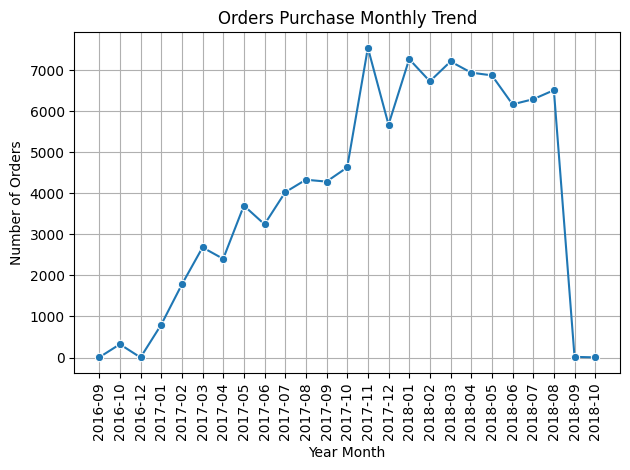

In [74]:
sns.lineplot(
    data=orders_purchase_monthly_trend,
    x="order_purchase_year_month",
    y="orders",
    marker="o"
)
plt.title("Orders Purchase Monthly Trend")
plt.xlabel("Year Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=90)
plt.grid()
plt.tight_layout()
plt.show()

In [75]:
orders_purchase_monthly_seasonality = clean_orders.groupby([
    "order_purchase_year",
    "order_purchase_month"
]).agg(
    orders=("order_id", "size")
).sort_values([
    "order_purchase_year",
    "order_purchase_month"
]).reset_index()

orders_purchase_monthly_seasonality

,order_purchase_year,order_purchase_month,orders
0,2016,9,4
1,2016,10,324
2,2016,12,1
3,2017,1,800
4,2017,2,1780
5,2017,3,2682
6,2017,4,2404
7,2017,5,3700
8,2017,6,3245
9,2017,7,4026


In [76]:
month_labels = [
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
    ]

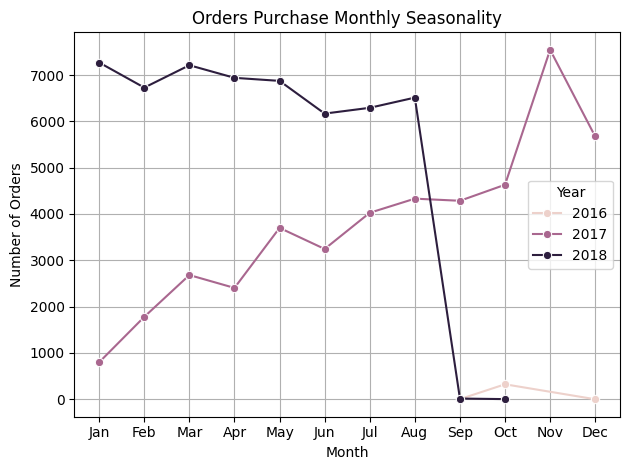

In [77]:
sns.lineplot(
    data=orders_purchase_monthly_seasonality,
    x="order_purchase_month",
    y="orders",
    hue="order_purchase_year",
    marker="o"
)
plt.title("Orders Purchase Monthly Seasonality")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(
    ticks=np.arange(1,13),
    labels=month_labels
)
plt.legend(title="Year")
plt.grid()
plt.tight_layout()
plt.show()

In [78]:
quarterly_purchase_orders = clean_orders.groupby(
    "order_purchase_quarter"
).agg(
    orders=("order_id", "size")
).sort_values(
    "order_purchase_quarter"
).reset_index()

quarterly_purchase_orders

,order_purchase_quarter,orders
0,1,26470
1,2,29328
2,3,25466
3,4,18177


In [79]:
quarter_labels = [
        "Q1", "Q2", "Q3", "Q4"
    ]

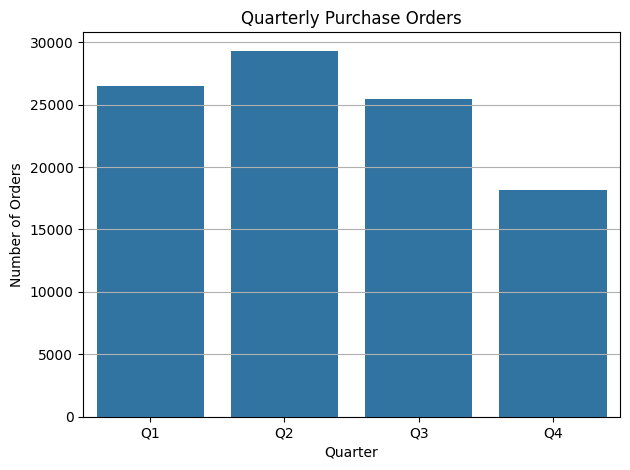

In [80]:
sns.barplot(
    data=quarterly_purchase_orders,
    x="order_purchase_quarter",
    y="orders"
)
plt.title("Quarterly Purchase Orders")
plt.xlabel("Quarter")
plt.ylabel("Number of Orders")
plt.xticks(
    ticks=np.arange(0,4),
    labels=quarter_labels
)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [81]:
daily_purchase_orders = clean_orders.groupby(
    "order_purchase_weekday"
).agg(
    orders=("order_id", "size")
).sort_values(
    "order_purchase_weekday"
).reset_index()

daily_purchase_orders

,order_purchase_weekday,orders
0,1,16196
1,2,15963
2,3,15552
3,4,14761
4,5,14122
5,6,10887
6,7,11960


In [82]:
day_labels = [
        "Mon", "Tue", "Wed", "Thu",
        "Fri", "Sat", "Sun"
]

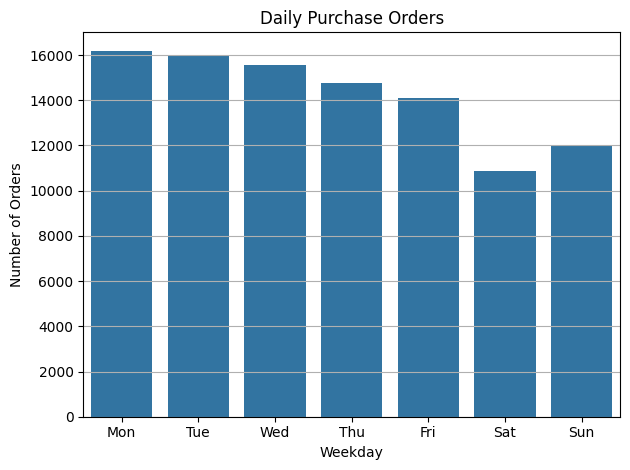

In [83]:
sns.barplot(
    data=daily_purchase_orders,
    x="order_purchase_weekday",
    y="orders"
)
plt.title("Daily Purchase Orders")
plt.xlabel("Weekday")
plt.ylabel("Number of Orders")
plt.xticks(
    ticks=np.arange(0,7),
    labels=day_labels        
)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

#### Order Approved At

In [84]:
(
    clean_orders["order_approved_at"].min(),
    clean_orders["order_approved_at"].max()
)

(Timestamp('2016-09-15 12:16:38'), Timestamp('2018-09-03 17:40:06'))

In [85]:
clean_orders["order_approved_at"].isna().sum()

np.int64(160)

In [86]:
orders_approved_monthly_trend = clean_orders.groupby(
    clean_orders["order_approved_at"]
        .dt.to_period("M").astype(str)
        .rename("order_approved_at_year_month")
).agg(
    orders=("order_id", "size")
).sort_values(
    "order_approved_at_year_month"
).reset_index()

orders_approved_monthly_trend

,order_approved_at_year_month,orders
0,2016-09,1
1,2016-10,320
2,2016-12,1
3,2017-01,760
4,2017-02,1765
5,2017-03,2689
6,2017-04,2374
7,2017-05,3693
8,2017-06,3252
9,2017-07,3974


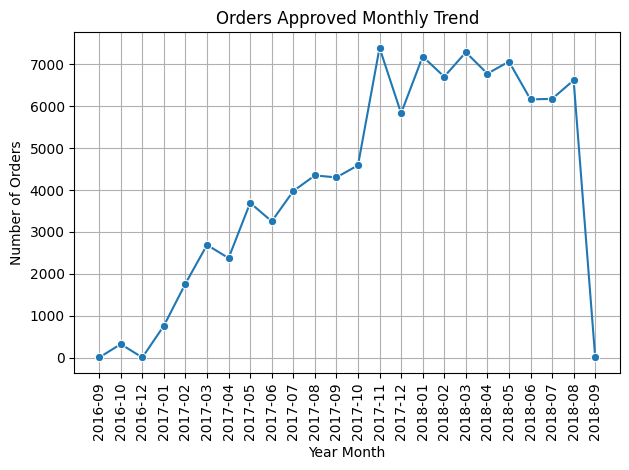

In [87]:
sns.lineplot(
    data=orders_approved_monthly_trend,
    x="order_approved_at_year_month",
    y="orders",
    marker="o"
)
plt.title("Orders Approved Monthly Trend")
plt.xlabel("Year Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=90)
plt.grid()
plt.tight_layout()
plt.show()

#### Order Delivered Carrier Date

In [88]:
(
    clean_orders["order_delivered_carrier_date"].min(),
    clean_orders["order_delivered_carrier_date"].max()
)

(Timestamp('2016-10-08 10:34:01'), Timestamp('2018-09-11 19:48:28'))

In [89]:
clean_orders["order_delivered_carrier_date"].isna().sum()

np.int64(1783)

In [118]:
orders_delivered_carrier_monthly_trend = clean_orders.groupby(
    clean_orders["order_delivered_carrier_date"]
        .dt.to_period("M").astype(str)
        .rename("order_delivered_carrier_year_month")
).agg(
    orders=("order_id", "size")
).sort_values(
    "order_delivered_carrier_year_month"
).reset_index()

orders_delivered_carrier_monthly_trend

,order_delivered_carrier_year_month,orders
0,2016-10,247
1,2016-11,32
2,2016-12,2
3,2017-01,612
4,2017-02,1517
5,2017-03,2717
6,2017-04,2141
7,2017-05,3709
8,2017-06,3263
9,2017-07,3710


In [ ]:
sns.lineplot(
    data=orders_delivered_carrier_monthly_trend,
    x="order_delivered_carrier_year_month",
    y="orders",
    marker="o"
)
plt.title("Orders Delivered Carrier Monthly Trend")
plt.xlabel("Year Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=90)
plt.grid()
plt.tight_layout()
plt.show()

#### Order Delivered Customer Date

In [ ]:
(
    clean_orders["order_delivered_customer_date"].min(),
    clean_orders["order_delivered_customer_date"].max()
)

In [ ]:
clean_orders["order_delivered_customer_date"].isna().sum()

In [ ]:
orders_delivered_customer_monthly_trend = clean_orders.groupby(
    clean_orders["order_delivered_customer_date"]
        .dt.to_period("M").astype(str)
        .rename("order_delivered_customer_year_month")
).agg(
    orders=("order_id", "size")
).sort_values(
    "order_delivered_customer_year_month"
).reset_index()

orders_delivered_customer_monthly_trend

In [ ]:
sns.lineplot(
    data=orders_delivered_customer_monthly_trend,
    x="order_delivered_customer_year_month",
    y="orders",
    marker="o"
)
plt.title("Orders Delivered Customer Monthly Trend")
plt.xlabel("Year Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=90)
plt.grid()
plt.tight_layout()
plt.show()

#### Order Estimated Delivery Date

In [ ]:
(
    clean_orders["order_estimated_delivery_date"].min(),
    clean_orders["order_estimated_delivery_date"].max()
)

In [ ]:
clean_orders["order_estimated_delivery_date"].isna().sum()

In [ ]:
orders_estimated_delivery_monthly_trend = clean_orders.groupby(
    clean_orders["order_estimated_delivery_date"]
        .dt.to_period("M").astype(str)
        .rename("order_estimated_delivery_year_month")
).agg(
    orders=("order_id", "size")
).sort_values(
    "order_estimated_delivery_year_month"
).reset_index()

orders_estimated_delivery_monthly_trend

In [ ]:
sns.lineplot(
    data=orders_estimated_delivery_monthly_trend,
    x="order_estimated_delivery_year_month",
    y="orders",
    marker="o"
)
plt.title("Orders Estimated Delivery Monthly Trend")
plt.xlabel("Year Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=90)
plt.grid()
plt.tight_layout()
plt.show()

#### Order Approval Duration Hours

In [ ]:
clean_orders["order_approval_duration_hours"].describe()

In [ ]:
sns.histplot(
    data=clean_orders,
    x="order_approval_duration_hours",
    bins=50
)
plt.title("Order Approval Duration Hours Distribution")
plt.xlabel("Hours")
plt.ylabel("Number of Orders")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [ ]:
sns.boxplot(
    data=clean_orders,
    y="order_approval_duration_hours"
)
plt.title("Order Approval Duration Hours Boxplot")
plt.ylabel("Hours")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

#### Order Shipping Time Days

In [ ]:
clean_orders["order_shipping_time_days"].describe()

In [ ]:
clean_orders.query(
    "order_shipping_time_days < 0"
)[[
    "order_id", "order_status", "order_purchase_timestamp",
    "order_delivered_carrier_date", "order_shipping_time_days"
]]

In [ ]:
sns.histplot(
    data=clean_orders,
    x="order_shipping_time_days",
    bins=np.arange(
        clean_orders["order_shipping_time_days"].min(),
        clean_orders["order_shipping_time_days"].max()+2
    )
)
plt.title("Order Shipping Time Days Distribution")
plt.xlabel("Days")
plt.ylabel("Number of Orders")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [ ]:
sns.boxplot(
    data=clean_orders,
    y="order_shipping_time_days"
)
plt.title("Order Shipping Time Days Boxplot")
plt.ylabel("Days")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

#### Order Transit Time Days

In [ ]:
clean_orders["order_transit_time_days"].describe()

In [ ]:
clean_orders.query(
    "order_transit_time_days < 0"
)[[
    "order_id", "order_status", "order_delivered_carrier_date",
    "order_delivered_customer_date", "order_transit_time_days"
]].shape[0]

In [ ]:
sns.histplot(
    data=clean_orders,
    x="order_transit_time_days",
    bins=np.arange(
        clean_orders["order_transit_time_days"].min(),
        clean_orders["order_transit_time_days"].max()+2
    )
)
plt.title("Order Transit Time Days Distribution")
plt.xlabel("Days")
plt.ylabel("Number of Orders")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [ ]:
sns.boxplot(
    data=clean_orders,
    y="order_transit_time_days",
)
plt.title("Order Transit Time Days Boxplot")
plt.ylabel("Days")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

#### Order Delivery Time Days

In [ ]:
clean_orders["order_delivery_time_days"].describe()

In [ ]:
sns.histplot(
    data=clean_orders,
    x="order_delivery_time_days",
    bins=np.arange(
        clean_orders["order_delivery_time_days"].min(),
        clean_orders["order_delivery_time_days"].max()+2
    )
)
plt.title("Order Delivery Time Days Distribution")
plt.xlabel("Days")
plt.ylabel("Number of Orders")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [ ]:
sns.boxplot(
    data=clean_orders,
    y="order_delivery_time_days"
)
plt.title("Order Delivery Time Days Boxplot")
plt.ylabel("Days")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

#### Order Delivery Delay Days

In [ ]:
clean_orders["order_delivery_delay_days"].describe()

In [ ]:
sns.histplot(
    data=clean_orders,
    x="order_delivery_delay_days",
    bins=np.arange(
        clean_orders["order_delivery_delay_days"].min(),
        clean_orders["order_delivery_delay_days"].max()+2
    )
)
plt.title("Order Delivery Delay Days Distribution")
plt.xlabel("Days")
plt.ylabel("Number of Orders")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [ ]:
sns.boxplot(
    data=clean_orders,
    y="order_delivery_delay_days"
)
plt.title("Order Delivery Delay Days Boxplot")
plt.ylabel("Days")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### Binary
La feature *order_delivery_on_time_flag* mostra che il 90% degli ordini è stato consegnato entro la data stimata. Tale percentuale sale a 93% se non si considera il 3% di valori mancanti. Per gli ordini consegnati in ritardo, la percentuale è pari al 7% circa.

#### Order Delivery On Time Flag

In [133]:
clean_orders["order_delivery_on_time_flag"].value_counts(
    dropna=False,
    normalize=True
)

order_delivery_on_time_flag
True     0.904466
False    0.065717
<NA>     0.029817
Name: proportion, dtype: Float64

In [135]:
clean_orders["order_delivery_on_time_flag"].value_counts(
    normalize=True
)

order_delivery_on_time_flag
True     0.932263
False    0.067737
Name: proportion, dtype: Float64

In [126]:
order_delivery_flag_plot = (
    clean_orders["order_delivery_on_time_flag"]
        .astype(str)
        .fillna("Missing")
        .replace({
            "True": "On Time",
            "False": "Late"
        })
)

order_delivery_flag_plot.value_counts()

order_delivery_on_time_flag
On Time    89941
Late        6535
Missing     2965
Name: count, dtype: int64

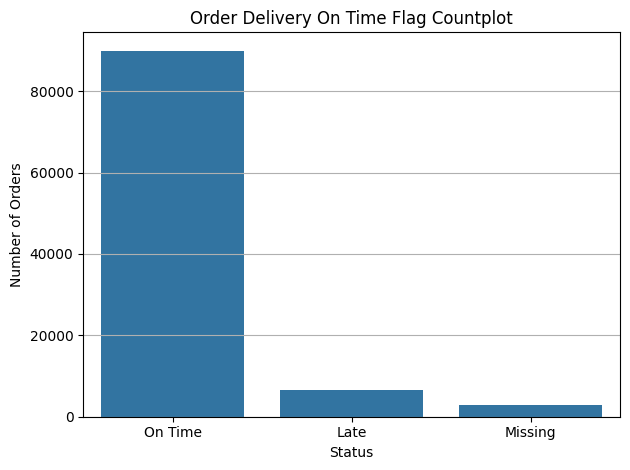

In [132]:
sns.countplot(
    x=order_delivery_flag_plot
)
plt.title("Order Delivery On Time Flag Countplot")
plt.xlabel("Status")
plt.ylabel("Number of Orders")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

## Customers

## Geolocation

## Sellers

## Products

## Category Name Translation

## Order Items

## Order Payments

## Order Reviews

# EDA

## Time Analysis

## Products Analysis

## Customers Analysis

## Geography Analysis

## Delivery Analysis 

## Reviews Analysis